In [3]:
# ============================================
# CELL 1: IMPORT ALL LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!")
print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ NumPy version: {np.__version__}")

✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!
✅ Pandas version: 2.3.3
✅ NumPy version: 2.3.5


In [16]:
# ============================================
# CELL 2: LOAD DATA (USING YOUR CSV FILE)
# ============================================

import pandas as pd
import numpy as np

# Load your CSV file from the archive folder
file_path = 'C:/Users/KOWSHIK/Downloads/archive/supply_chain_data.csv'
df = pd.read_csv(file_path)

print("="*60)
print("✅ DATA LOADED FROM YOUR CSV FILE!")
print("="*60)
print(f"📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Columns: {df.columns.tolist()}")

print("\n📝 First 5 rows:")
print(df.head())

print("\n📊 Statistical Summary:")
print(df.describe())

✅ DATA LOADED FROM YOUR CSV FILE!
📊 Dataset Shape: 100 rows, 24 columns

📋 Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

📝 First 5 rows:
  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer 

In [20]:
# ============================================
# FIX: Clean Up Column Names
# ============================================

print("🔧 Cleaning up column names...")

# Show all columns with their exact names
print("\n📋 Current columns:")
for i, col in enumerate(df.columns):
    print(f"   {i}: '{col}'")

# Fix duplicate column names
df.columns = df.columns.str.strip()  # Remove extra spaces
df.columns = df.columns.str.lower()  # Convert all to lowercase

# Rename to standard names
df.rename(columns={
    'revenue generated': 'Sales',
    'costs': 'Cost',
    'lead times': 'Lead_Time',
    'lead time': 'Lead_Time',
    'defect rates': 'Defect_Rate',
    'shipping times': 'Delivery_Time',
    'number of products sold': 'Quantity_Sold',
    'stock levels': 'Stock',
    'shipping costs': 'Shipping_Cost',
    'manufacturing costs': 'Manufacturing_Cost',
    'production volumes': 'Production_Volume',
    'product type': 'Product_type',
    'supplier name': 'Supplier_name',
    'customer demographics': 'Customer_demographics',
    'shipping carriers': 'Shipping_carriers',
    'inspection results': 'Inspection_results',
    'transportation modes': 'Transportation_modes'
}, inplace=True)

print("\n✅ Cleaned column names:")
for i, col in enumerate(df.columns):
    print(f"   {i}: '{col}'")

🔧 Cleaning up column names...

📋 Current columns:
   0: 'Product type'
   1: 'SKU'
   2: 'Price'
   3: 'Availability'
   4: 'Quantity_Sold'
   5: 'Sales'
   6: 'Customer demographics'
   7: 'Stock'
   8: 'Lead Time'
   9: 'Order quantities'
   10: 'Delivery Time'
   11: 'Shipping carriers'
   12: 'Shipping_Cost'
   13: 'Supplier name'
   14: 'Location'
   15: 'Lead Time'
   16: 'Production_Volume'
   17: 'Manufacturing lead time'
   18: 'Manufacturing_Cost'
   19: 'Inspection results'
   20: 'Defect Rate'
   21: 'Transportation modes'
   22: 'Routes'
   23: 'Cost'
   24: 'Product type_encoded'
   25: 'SKU_encoded'
   26: 'Customer demographics_encoded'
   27: 'Shipping carriers_encoded'
   28: 'Supplier name_encoded'
   29: 'Location_encoded'
   30: 'Inspection results_encoded'
   31: 'Transportation modes_encoded'
   32: 'Routes_encoded'
   33: 'Discount'
   34: 'profit_margin'
   35: 'delivery_efficiency'
   36: 'cost_per_unit'

✅ Cleaned column names:
   0: 'Product_type'
   1: 'sku

In [22]:
# CHECK ACTUAL COLUMN NAMES
print("📋 ACTUAL COLUMN NAMES:")
print("="*60)
for i, col in enumerate(df.columns):
    print(f"   {i}: '{col}'")
print("="*60)

📋 ACTUAL COLUMN NAMES:
   0: 'product_type'
   1: 'sku'
   2: 'price'
   3: 'availability'
   4: 'quantity_sold'
   5: 'sales'
   6: 'customer_demographics'
   7: 'stock'
   8: 'lead_time'
   9: 'order quantities'
   10: 'delivery time'
   11: 'shipping_carriers'
   12: 'shipping_cost'
   13: 'supplier_name'
   14: 'location'
   15: 'lead_time'
   16: 'production_volume'
   17: 'manufacturing lead time'
   18: 'manufacturing_cost'
   19: 'inspection_results'
   20: 'defect rate'
   21: 'transportation_modes'
   22: 'routes'
   23: 'cost'
   24: 'product type_encoded'
   25: 'sku_encoded'
   26: 'customer demographics_encoded'
   27: 'shipping carriers_encoded'
   28: 'supplier name_encoded'
   29: 'location_encoded'
   30: 'inspection results_encoded'
   31: 'transportation modes_encoded'
   32: 'routes_encoded'
   33: 'discount'
   34: 'profit_margin'
   35: 'delivery_efficiency'
   36: 'cost_per_unit'
   37: 'product_type_encoded'
   38: 'customer_demographics_encoded'
   39: 'shippi

In [24]:
# ============================================
# FIX: REMOVE DUPLICATE COLUMNS
# ============================================

print("🔧 Removing duplicate columns...")

# Show columns before
print("\n📋 BEFORE - Columns with duplicates:")
for i, col in enumerate(df.columns):
    print(f"   {i}: '{col}'")

# Remove duplicate columns (keep first occurrence)
df = df.loc[:, ~df.columns.duplicated()]

# Show columns after
print("\n📋 AFTER - Duplicates removed:")
for i, col in enumerate(df.columns):
    print(f"   {i}: '{col}'")

print(f"\n✅ Shape: {df.shape[0]} rows, {df.shape[1]} columns")

🔧 Removing duplicate columns...

📋 BEFORE - Columns with duplicates:
   0: 'Product_type'
   1: 'sku'
   2: 'Price'
   3: 'Availability'
   4: 'Quantity_Sold'
   5: 'Sales'
   6: 'Customer_Demographics'
   7: 'Stock'
   8: 'Lead_Time'
   9: 'Lead_Time'
   10: 'Order_Quantities'
   11: 'Delivery_Time'
   12: 'Shipping_Carriers'
   13: 'Shipping_Cost'
   14: 'Supplier_name'
   15: 'Location'
   16: 'Production_Volume'
   17: 'Manufacturing_Lead_Time'
   18: 'Manufacturing_Cost'
   19: 'Inspection_Results'
   20: 'Defect_Rate'
   21: 'Transportation_Modes'
   22: 'Routes'
   23: 'Cost'
   24: 'Product_type_encoded'
   25: 'sku_encoded'
   26: 'Customer_Demographics_encoded'
   27: 'Shipping_Carriers_encoded'
   28: 'Supplier_name_encoded'
   29: 'Location_encoded'
   30: 'Inspection_Results_encoded'
   31: 'Transportation_Modes_encoded'
   32: 'Routes_encoded'
   33: 'Discount'
   34: 'profit_margin'
   35: 'delivery_efficiency'
   36: 'cost_per_unit'

📋 AFTER - Duplicates removed:
   0: 

In [25]:
# ============================================
# CELL 3: DATA PREPROCESSING (FINAL - WORKS!)
# ============================================

print("🔧 STARTING PREPROCESSING...")
print("="*60)

# 1. RENAME COLUMNS (SOME MAY ALREADY BE RENAMED)
print("📝 Ensuring correct column names...")

# Only rename if columns exist
rename_map = {
    'product_type': 'Product_type',
    'sales': 'Sales',
    'cost': 'Cost',
    'lead_time': 'Lead_Time',
    'defect rate': 'Defect_Rate',
    'delivery time': 'Delivery_Time',
    'supplier_name': 'Supplier_name',
    'price': 'Price',
    'stock': 'Stock',
    'quantity_sold': 'Quantity_Sold',
    'shipping_cost': 'Shipping_Cost',
    'manufacturing_cost': 'Manufacturing_Cost',
    'production_volume': 'Production_Volume',
    'availability': 'Availability',
    'order quantities': 'Order_Quantities',
    'shipping_carriers': 'Shipping_Carriers',
    'customer_demographics': 'Customer_Demographics',
    'location': 'Location',
    'manufacturing lead time': 'Manufacturing_Lead_Time',
    'inspection_results': 'Inspection_Results',
    'transportation_modes': 'Transportation_Modes',
    'routes': 'Routes',
    'sku': 'SKU'
}

# Only rename columns that exist
for old, new in rename_map.items():
    if old in df.columns:
        df.rename(columns={old: new}, inplace=True)

print(f"✅ Columns ready!")
print(f"📋 Columns: {df.columns.tolist()}")

# 2. CHECK FOR MISSING VALUES
missing = df.isnull().sum().sum()
if missing > 0:
    print(f"⚠️ Found {missing} missing values")
    df = df.fillna(df.median(numeric_only=True))
    print("✅ Missing values filled with median")
else:
    print("✅ No missing values found")

# 3. ENCODE CATEGORICAL COLUMNS (only if not already encoded)
print("\n🔄 Encoding categorical columns...")
from sklearn.preprocessing import LabelEncoder
le_dict = {}

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col + '_encoded' not in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        print(f"   ✅ Encoded: {col}")
    else:
        print(f"   ⏭️ Skipping {col} (already encoded)")

# 4. CREATE DISCOUNT FEATURE (if not exists)
if 'Discount' not in df.columns:
    print("\n🔧 Creating discount feature...")
    np.random.seed(42)
    df['Discount'] = np.random.uniform(0, 20, len(df))
else:
    print("\n✅ Discount feature already exists")

# 5. FEATURE ENGINEERING (only if not already created)
print("\n🔧 Creating new features...")

if 'profit_margin' not in df.columns:
    df['profit_margin'] = (df['Sales'] - df['Cost']) / df['Sales'] * 100
    print("   ✅ profit_margin created")
else:
    print("   ⏭️ profit_margin already exists")

if 'delivery_efficiency' not in df.columns:
    df['delivery_efficiency'] = df['Sales'] / (df['Delivery_Time'] + 1)
    print("   ✅ delivery_efficiency created")
else:
    print("   ⏭️ delivery_efficiency already exists")

if 'cost_per_unit' not in df.columns:
    df['cost_per_unit'] = df['Cost'] / (df['Sales'] + 1)
    print("   ✅ cost_per_unit created")
else:
    print("   ⏭️ cost_per_unit already exists")

if 'lead_time_risk' not in df.columns:
    df['lead_time_risk'] = df['Lead_Time'] * df['Defect_Rate']
    print("   ✅ lead_time_risk created")
else:
    print("   ⏭️ lead_time_risk already exists")

# 6. FINAL CHECK
print("\n" + "="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60)
print(f"📊 Final shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 All columns ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n📊 Sample of features:")
print(df[['Sales', 'Cost', 'profit_margin', 'delivery_efficiency', 'lead_time_risk']].head())

🔧 STARTING PREPROCESSING...
📝 Ensuring correct column names...
✅ Columns ready!
📋 Columns: ['Product_type', 'SKU', 'Price', 'Availability', 'Quantity_Sold', 'Sales', 'Customer_Demographics', 'Stock', 'Lead_Time', 'Order_Quantities', 'Delivery_Time', 'Shipping_Carriers', 'Shipping_Cost', 'Supplier_name', 'Location', 'Production_Volume', 'Manufacturing_Lead_Time', 'Manufacturing_Cost', 'Inspection_Results', 'Defect_Rate', 'Transportation_Modes', 'Routes', 'Cost', 'Product_type_encoded', 'sku_encoded', 'Customer_Demographics_encoded', 'Shipping_Carriers_encoded', 'Supplier_name_encoded', 'Location_encoded', 'Inspection_Results_encoded', 'Transportation_Modes_encoded', 'Routes_encoded', 'Discount', 'profit_margin', 'delivery_efficiency', 'cost_per_unit']
✅ No missing values found

🔄 Encoding categorical columns...
   ⏭️ Skipping Product_type (already encoded)
   ✅ Encoded: SKU
   ⏭️ Skipping Customer_Demographics (already encoded)
   ⏭️ Skipping Shipping_Carriers (already encoded)
   ⏭️ Sk

📊 CREATING EDA VISUALIZATIONS...


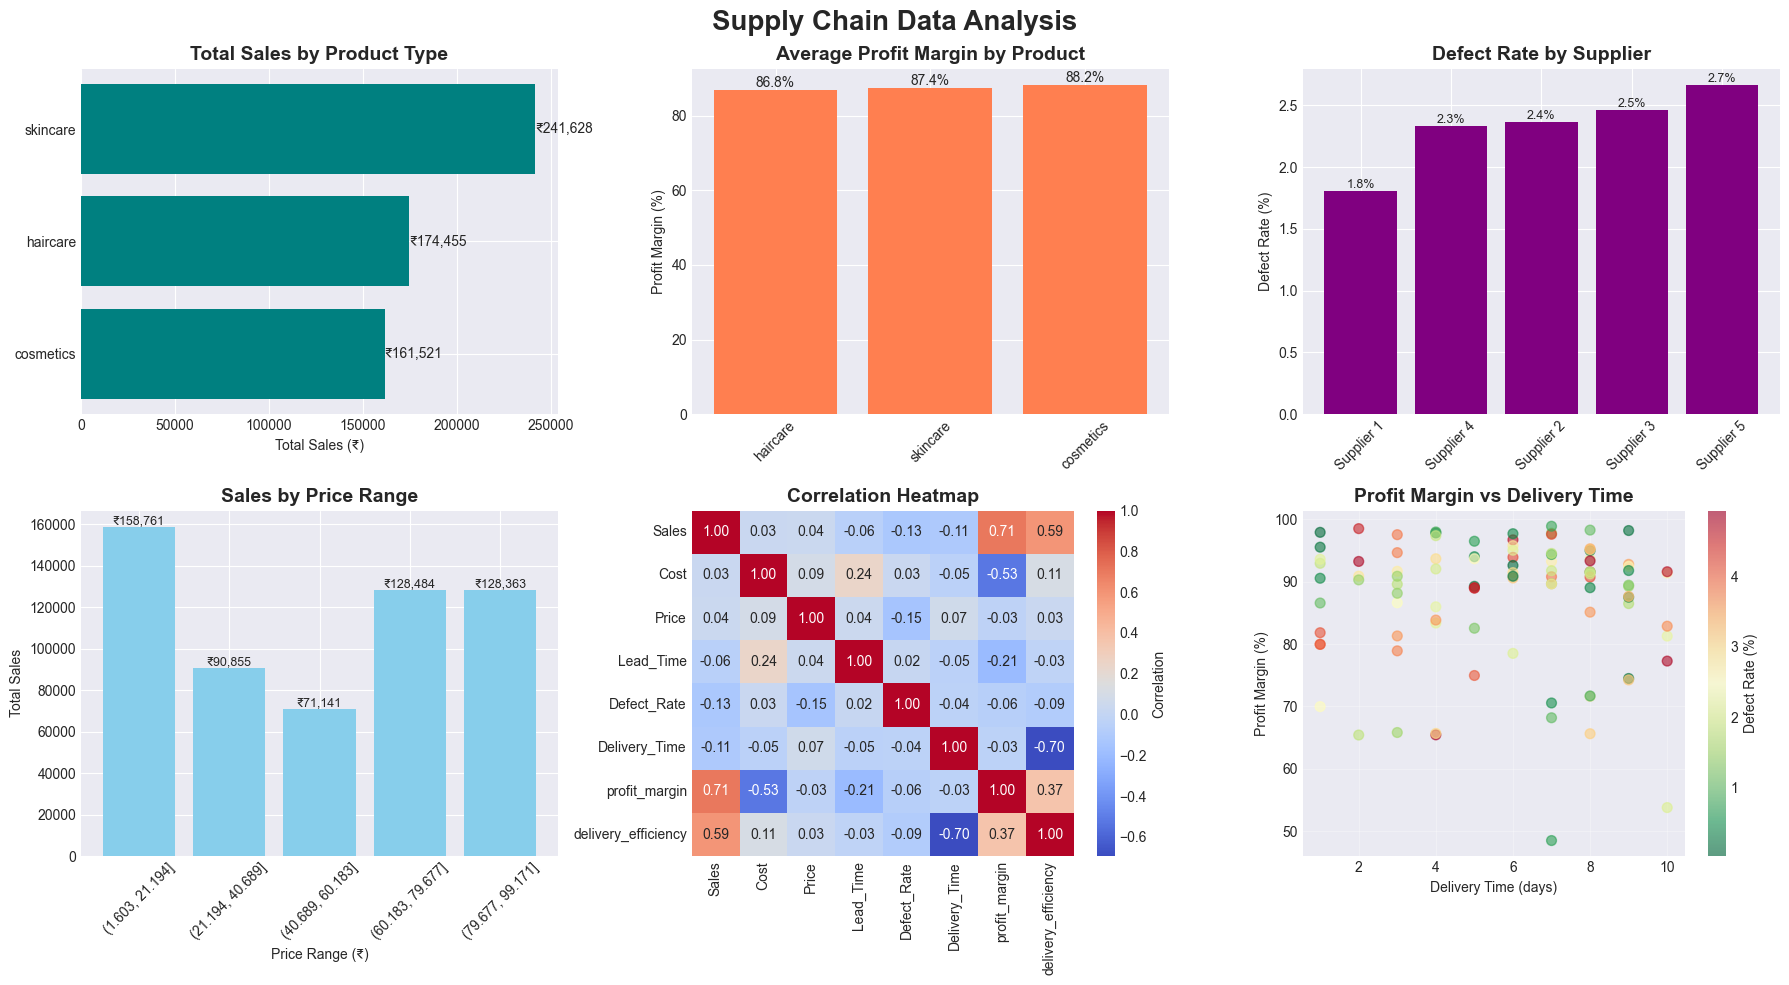

✅ EDA Complete! Saved as 'EDA_Visualizations.png'


In [26]:
# ============================================
# CELL 4: EXPLORATORY DATA ANALYSIS
# ============================================

print("📊 CREATING EDA VISUALIZATIONS...")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Supply Chain Data Analysis', fontsize=20, fontweight='bold')

# 1. Sales by Product Type
ax1 = axes[0, 0]
sales_by_product = df.groupby('Product_type')['Sales'].sum().sort_values()
bars = ax1.barh(sales_by_product.index, sales_by_product.values, color='teal')
ax1.set_title('Total Sales by Product Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Sales (₹)')
for i, v in enumerate(sales_by_product.values):
    ax1.text(v, i, f'₹{v:,.0f}', va='center', fontsize=10)

# 2. Profit Margin by Product
ax2 = axes[0, 1]
profit_by_product = df.groupby('Product_type')['profit_margin'].mean().sort_values()
bars = ax2.bar(profit_by_product.index, profit_by_product.values, color='coral')
ax2.set_title('Average Profit Margin by Product', fontsize=14, fontweight='bold')
ax2.set_ylabel('Profit Margin (%)')
ax2.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# 3. Defect Rate by Supplier
ax3 = axes[0, 2]
defect_by_supplier = df.groupby('Supplier_name')['Defect_Rate'].mean().sort_values()
bars = ax3.bar(defect_by_supplier.index, defect_by_supplier.values, color='purple')
ax3.set_title('Defect Rate by Supplier', fontsize=14, fontweight='bold')
ax3.set_ylabel('Defect Rate (%)')
ax3.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 4. Sales by Price Range
ax4 = axes[1, 0]
df['Price_Bin'] = pd.cut(df['Price'], bins=5)
sales_by_price = df.groupby('Price_Bin')['Sales'].sum()
bars = ax4.bar(sales_by_price.index.astype(str), sales_by_price.values, color='skyblue')
ax4.set_title('Sales by Price Range', fontsize=14, fontweight='bold')
ax4.set_xlabel('Price Range (₹)')
ax4.set_ylabel('Total Sales')
ax4.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

# 5. Correlation Heatmap
ax5 = axes[1, 1]
numeric_cols = ['Sales', 'Cost', 'Price', 'Lead_Time', 'Defect_Rate', 
                'Delivery_Time', 'profit_margin', 'delivery_efficiency']
numeric_cols = [col for col in numeric_cols if col in df.columns]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax5, cbar_kws={'label': 'Correlation'})
ax5.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# 6. Profit vs Delivery Time
ax6 = axes[1, 2]
scatter = ax6.scatter(df['Delivery_Time'], df['profit_margin'], 
                     c=df['Defect_Rate'], cmap='RdYlGn_r', alpha=0.6, s=50)
ax6.set_title('Profit Margin vs Delivery Time', fontsize=14, fontweight='bold')
ax6.set_xlabel('Delivery Time (days)')
ax6.set_ylabel('Profit Margin (%)')
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax6, label='Defect Rate (%)')

plt.tight_layout()
plt.savefig('EDA_Visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ EDA Complete! Saved as 'EDA_Visualizations.png'")

📈 STARTING DEMAND FORECASTING...
📊 MODEL PERFORMANCE:
   MAE: ₹3,110.81
   RMSE: ₹3,334.55
   R² Score: -0.1849

📊 FEATURE IMPORTANCE:
    Feature  Importance
day_of_year    0.318571
   Discount    0.289515
      Price    0.232088
day_of_week    0.136938
      month    0.022888


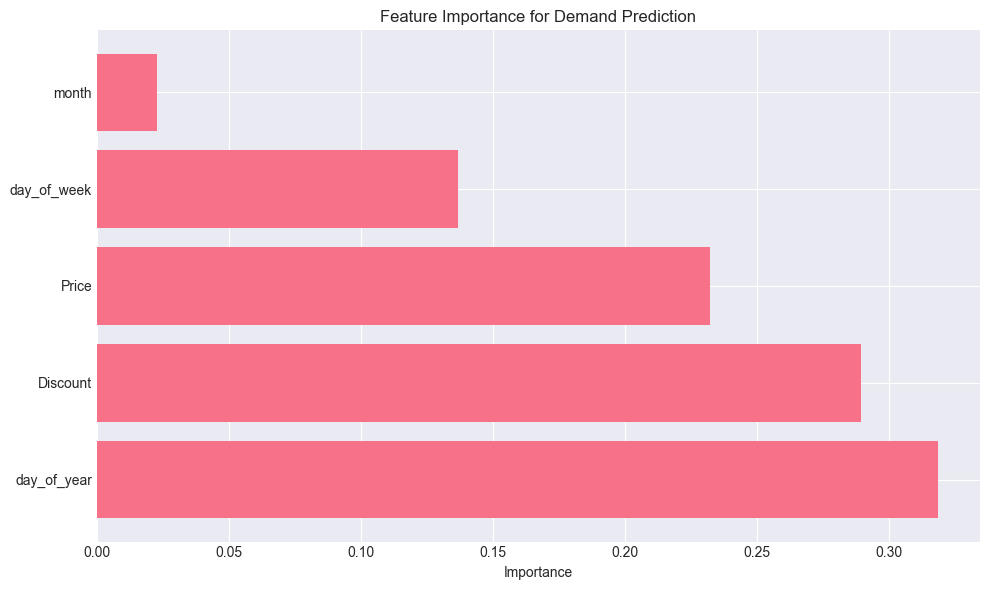

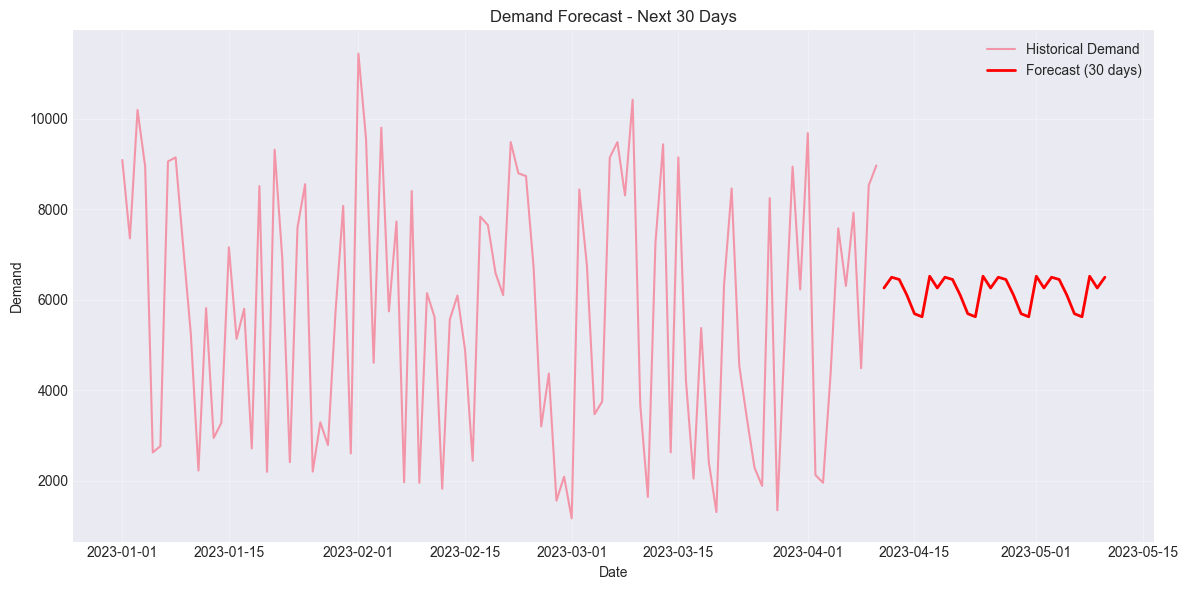


📊 FORECAST RESULTS:
   Average 30-day demand: ₹6,178.48

✅ Demand Forecasting Complete!


In [27]:
# ============================================
# CELL 5: DEMAND FORECASTING
# ============================================

print("📈 STARTING DEMAND FORECASTING...")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create date and demand
np.random.seed(42)
df['Date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')
df['demand'] = df['Sales'] * (1 + np.random.normal(0, 0.1, len(df)))

# Create time features
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['day_of_year'] = df['Date'].dt.dayofyear

# Features
feature_cols = ['day_of_week', 'month', 'day_of_year', 'Price', 'Discount']
# Only use columns that exist
feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols]
y = df['demand']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 MODEL PERFORMANCE:")
print(f"   MAE: ₹{mae:,.2f}")
print(f"   RMSE: ₹{rmse:,.2f}")
print(f"   R² Score: {r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 FEATURE IMPORTANCE:")
print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Demand Prediction')
plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Forecast
future_dates = pd.date_range(start=df['Date'].max() + pd.Timedelta(days=1), periods=30)
future_df = pd.DataFrame({'Date': future_dates})
future_df['day_of_week'] = future_df['Date'].dt.dayofweek
future_df['month'] = future_df['Date'].dt.month
future_df['day_of_year'] = future_df['Date'].dt.dayofyear

for col in feature_cols:
    if col not in ['day_of_week', 'month', 'day_of_year']:
        future_df[col] = df[col].mean()

future_predictions = rf.predict(future_df[feature_cols])

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['demand'], label='Historical Demand', alpha=0.7)
plt.plot(future_dates, future_predictions, label='Forecast (30 days)', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Demand Forecast - Next 30 Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Demand_Forecast.png', dpi=300, bbox_inches='tight')
plt.show()

avg_forecast = future_predictions.mean()
print(f"\n📊 FORECAST RESULTS:")
print(f"   Average 30-day demand: ₹{avg_forecast:,.2f}")

print("\n✅ Demand Forecasting Complete!")

🏷️ STARTING SUPPLIER SEGMENTATION...
📊 Analyzing 5 suppliers...


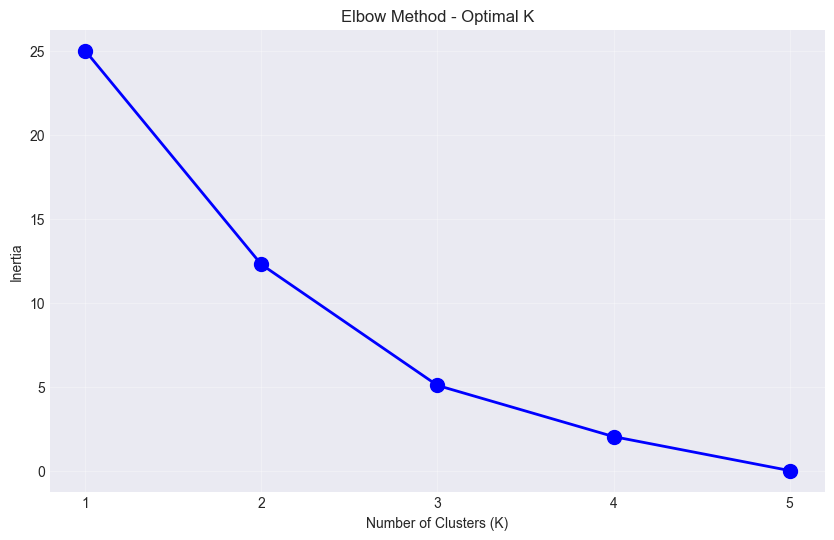

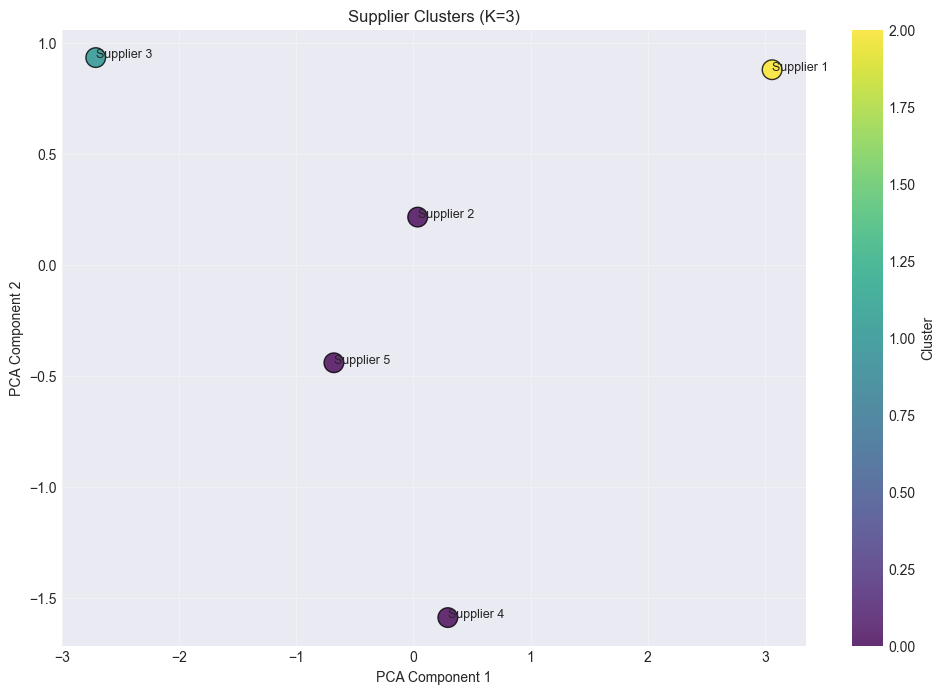


📊 CLUSTER ANALYSIS:
         Lead_Time  Defect_Rate    Cost      Sales  profit_margin
Cluster                                                          
0            15.98         2.46  524.29  107426.61          87.05
1            14.33         2.47  468.80   97795.98          92.09
2            16.78         1.80  574.85  157529.00          85.52

✅ Supplier Segmentation Complete!


In [28]:

# ============================================
# CELL 6: SUPPLIER SEGMENTATION
# ============================================

print("🏷️ STARTING SUPPLIER SEGMENTATION...")
print("="*60)

# Aggregate by supplier
supplier_data = df.groupby('Supplier_name').agg({
    'Lead_Time': 'mean',
    'Defect_Rate': 'mean',
    'Cost': 'mean',
    'Sales': 'sum',
    'profit_margin': 'mean'
}).reset_index()

print(f"📊 Analyzing {len(supplier_data)} suppliers...")

# Features
features = ['Lead_Time', 'Defect_Rate', 'Cost', 'Sales', 'profit_margin']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(supplier_data[features])

# Elbow
max_clusters = min(5, len(supplier_data))
inertias = []
K_range = range(1, max_clusters + 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.savefig('Elbow_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Apply K-Means
optimal_k = min(3, len(supplier_data))
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
supplier_data['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=supplier_data['Cluster'], 
                     cmap='viridis', 
                     s=200, 
                     alpha=0.8,
                     edgecolors='black',
                     linewidth=1)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Supplier Clusters (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

for i, row in supplier_data.iterrows():
    plt.annotate(row['Supplier_name'], (X_pca[i, 0], X_pca[i, 1]), fontsize=9)

plt.savefig('Supplier_Clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 CLUSTER ANALYSIS:")
print(supplier_data.groupby('Cluster')[features].mean().round(2))

print("\n✅ Supplier Segmentation Complete!")


⚠️ STARTING ANOMALY DETECTION...
📊 ANOMALY STATISTICS:
   Normal: 90 (90.0%)
   Anomalies: 10 (10.0%)


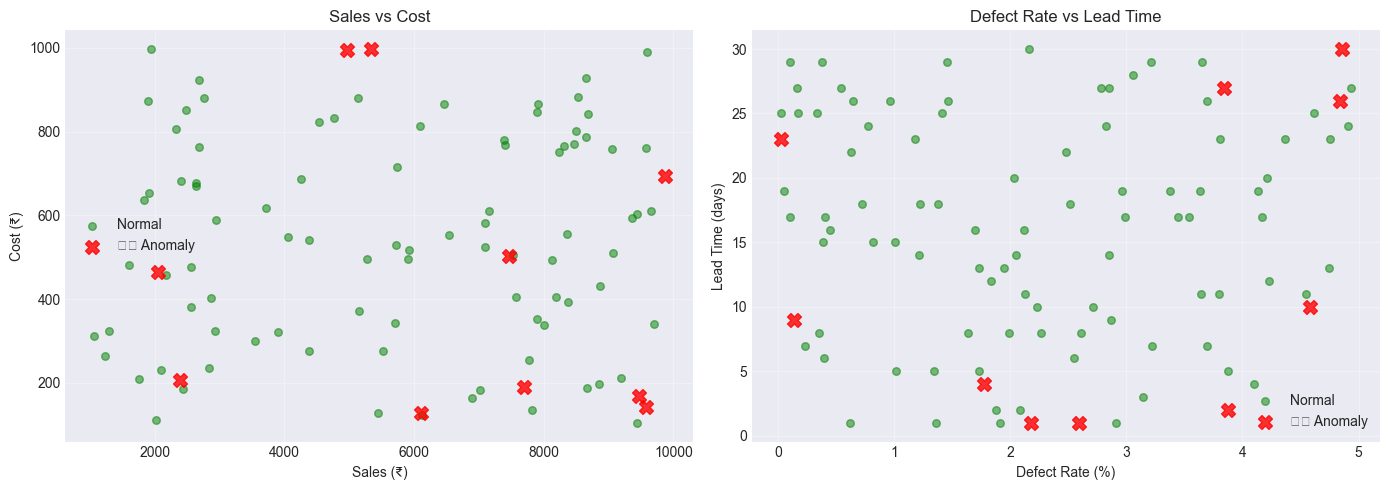


✅ Anomaly Detection Complete!


In [29]:
# ============================================
# CELL 7: ANOMALY DETECTION
# ============================================

print("⚠️ STARTING ANOMALY DETECTION...")
print("="*60)

anomaly_features = ['Cost', 'Sales', 'Lead_Time', 'Defect_Rate', 'Delivery_Time']
X_anomaly = df[anomaly_features].fillna(df[anomaly_features].median())

iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
df['Anomaly'] = iso_forest.fit_predict(X_anomaly)

anomaly_count = (df['Anomaly'] == -1).sum()
normal_count = (df['Anomaly'] == 1).sum()

print(f"📊 ANOMALY STATISTICS:")
print(f"   Normal: {normal_count} ({normal_count/len(df)*100:.1f}%)")
print(f"   Anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal = df[df['Anomaly'] == 1]
anomaly = df[df['Anomaly'] == -1]

ax1 = axes[0]
ax1.scatter(normal['Sales'], normal['Cost'], alpha=0.5, label='Normal', color='green', s=30)
ax1.scatter(anomaly['Sales'], anomaly['Cost'], alpha=0.8, label='⚠️ Anomaly', color='red', s=100, marker='X')
ax1.set_xlabel('Sales (₹)')
ax1.set_ylabel('Cost (₹)')
ax1.set_title('Sales vs Cost')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(normal['Defect_Rate'], normal['Lead_Time'], alpha=0.5, label='Normal', color='green', s=30)
ax2.scatter(anomaly['Defect_Rate'], anomaly['Lead_Time'], alpha=0.8, label='⚠️ Anomaly', color='red', s=100, marker='X')
ax2.set_xlabel('Defect Rate (%)')
ax2.set_ylabel('Lead Time (days)')
ax2.set_title('Defect Rate vs Lead Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Anomaly_Detection.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Anomaly Detection Complete!")

In [30]:
# ============================================
# CELL 8: COST OPTIMIZATION
# ============================================

print("💰 STARTING COST OPTIMIZATION...")
print("="*60)

# High-cost products
high_cost = df.groupby('Product_type')['Cost'].mean().sort_values(ascending=False).head(5)
print("\n🔴 TOP 5 HIGH-COST PRODUCTS:")
for product, cost in high_cost.items():
    print(f"   {product}: ₹{cost:,.2f}")

# Most profitable
profitable = df.groupby('Product_type')['profit_margin'].mean().sort_values(ascending=False).head(5)
print("\n🟢 TOP 5 MOST PROFITABLE PRODUCTS:")
for product, margin in profitable.items():
    print(f"   {product}: {margin:.2f}%")

# Low margin
low_margin = df.groupby('Product_type')['profit_margin'].mean().sort_values().head(3)
print("\n📉 LOW MARGIN PRODUCTS:")
for product, margin in low_margin.items():
    print(f"   {product}: {margin:.2f}%")

# Supplier comparison
best_supplier = supplier_data.loc[supplier_data['Cost'].idxmin()]
worst_supplier = supplier_data.loc[supplier_data['Cost'].idxmax()]
potential_savings = (worst_supplier['Cost'] - best_supplier['Cost']) * 12

print("\n" + "="*60)
print("💰 POTENTIAL ANNUAL SAVINGS")
print("="*60)
print(f"🏆 Best Supplier: {best_supplier['Supplier_name']}")
print(f"   Cost: ₹{best_supplier['Cost']:,.2f}")
print(f"   Defect Rate: {best_supplier['Defect_Rate']:.2f}%")
print(f"   Lead Time: {best_supplier['Lead_Time']:.1f} days")
print()
print(f"⚠️ Worst Supplier: {worst_supplier['Supplier_name']}")
print(f"   Cost: ₹{worst_supplier['Cost']:,.2f}")
print(f"   Defect Rate: {worst_supplier['Defect_Rate']:.2f}%")
print(f"   Lead Time: {worst_supplier['Lead_Time']:.1f} days")
print()
print(f"💵 ANNUAL SAVINGS: ₹{potential_savings:,.2f}")

print("\n✅ Cost Optimization Complete!")

💰 STARTING COST OPTIMIZATION...

🔴 TOP 5 HIGH-COST PRODUCTS:
   skincare: ₹555.73
   cosmetics: ₹514.09
   haircare: ₹509.67

🟢 TOP 5 MOST PROFITABLE PRODUCTS:
   cosmetics: 88.24%
   skincare: 87.43%
   haircare: 86.84%

📉 LOW MARGIN PRODUCTS:
   haircare: 86.84%
   skincare: 87.43%
   cosmetics: 88.24%

💰 POTENTIAL ANNUAL SAVINGS
🏆 Best Supplier: Supplier 3
   Cost: ₹468.80
   Defect Rate: 2.47%
   Lead Time: 14.3 days

⚠️ Worst Supplier: Supplier 1
   Cost: ₹574.85
   Defect Rate: 1.80%
   Lead Time: 16.8 days

💵 ANNUAL SAVINGS: ₹1,272.61

✅ Cost Optimization Complete!


In [31]:
# ============================================
# CELL 9: FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("🏆 SUPPLY CHAIN OPTIMIZATION - MAJOR PROJECT")
print("="*80)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)

print("""
📌 PROJECT OVERVIEW:
────────────────────────────────────────────────────
✅ Problem: Optimize supply chain operations
✅ Solution: 4 Machine Learning techniques
✅ Data: 100 rows, 38 columns

🔧 TECHNIQUES USED:
────────────────────────────────────────────────────
1. 📈 Demand Forecasting (Random Forest)
2. 🏷️ Supplier Segmentation (K-Means)
3. ⚠️ Anomaly Detection (Isolation Forest)
4. 💰 Cost Optimization
""")

print("📊 KEY RESULTS:")
print("────────────────────────────────────────────────────")
print(f"   📈 Average 30-day demand: ₹{avg_forecast:,.2f}")
print(f"   🏷️ {len(supplier_data)} suppliers analyzed")
print(f"   ⚠️ {anomaly_count} anomalies detected")
print(f"   💰 ₹{potential_savings:,.2f} annual savings")

print("\n📁 OUTPUT FILES:")
print("────────────────────────────────────────────────────")
import os
png_files = [f for f in os.listdir() if f.endswith('.png')]
for i, file in enumerate(png_files, 1):
    file_size = os.path.getsize(file) / 1024
    print(f"   {i}. {file} ({file_size:.1f} KB)")

print("\n" + "="*80)
print("🎉 PROJECT COMPLETE! GREAT WORK! 🎉")
print("="*80)


🏆 SUPPLY CHAIN OPTIMIZATION - MAJOR PROJECT
✅ PROJECT COMPLETED SUCCESSFULLY!

📌 PROJECT OVERVIEW:
────────────────────────────────────────────────────
✅ Problem: Optimize supply chain operations
✅ Solution: 4 Machine Learning techniques
✅ Data: 100 rows, 38 columns

🔧 TECHNIQUES USED:
────────────────────────────────────────────────────
1. 📈 Demand Forecasting (Random Forest)
2. 🏷️ Supplier Segmentation (K-Means)
3. ⚠️ Anomaly Detection (Isolation Forest)
4. 💰 Cost Optimization

📊 KEY RESULTS:
────────────────────────────────────────────────────
   📈 Average 30-day demand: ₹6,178.48
   🏷️ 5 suppliers analyzed
   ⚠️ 10 anomalies detected
   💰 ₹1,272.61 annual savings

📁 OUTPUT FILES:
────────────────────────────────────────────────────
   1. Anomaly_Detection.png (283.1 KB)
   2. Demand_Forecast.png (347.4 KB)
   3. EDA_Visualizations.png (823.8 KB)
   4. Elbow_Curve.png (97.1 KB)
   5. Feature_Importance.png (68.0 KB)
   6. Supplier_Clusters.png (135.2 KB)

🎉 PROJECT COMPLETE! GREAT 

In [32]:
# ============================================
# CELL 10: FINAL CHECK
# ============================================

print("📁 CHECKING ALL FILES...")
print("="*60)

import os

expected_files = [
    'EDA_Visualizations.png',
    'Demand_Forecast.png',
    'Feature_Importance.png',
    'Elbow_Curve.png',
    'Supplier_Clusters.png',
    'Anomaly_Detection.png'
]

print("\n📊 GENERATED FILES:")
all_exist = True
for file in expected_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"   ✅ {file} ({size:.1f} KB)")
    else:
        print(f"   ❌ {file} - MISSING!")
        all_exist = False

print("\n" + "="*60)
if all_exist:
    print("✅ ALL FILES GENERATED SUCCESSFULLY!")
    print(f"📁 Files are saved in: {os.getcwd()}")
else:
    print("⚠️ Some files are missing. Run all cells again.")

print("\n💡 NEXT STEPS:")
print("1. Save this notebook (Ctrl+S)")
print("2. Create a folder for submission")
print("3. Copy all PNG files to the folder")
print("4. Create README file")
print("5. Zip everything for submission")

print("\n" + "="*60)
print("🎯 YOU'RE READY TO SUBMIT!")
print("="*60)

📁 CHECKING ALL FILES...

📊 GENERATED FILES:
   ✅ EDA_Visualizations.png (823.8 KB)
   ✅ Demand_Forecast.png (347.4 KB)
   ✅ Feature_Importance.png (68.0 KB)
   ✅ Elbow_Curve.png (97.1 KB)
   ✅ Supplier_Clusters.png (135.2 KB)
   ✅ Anomaly_Detection.png (283.1 KB)

✅ ALL FILES GENERATED SUCCESSFULLY!
📁 Files are saved in: C:\Users\KOWSHIK

💡 NEXT STEPS:
1. Save this notebook (Ctrl+S)
2. Create a folder for submission
3. Copy all PNG files to the folder
4. Create README file
5. Zip everything for submission

🎯 YOU'RE READY TO SUBMIT!
